In [1]:
import sys

print(sys.executable)
c

/Users/marya/qiskit-project/bin/python


In [2]:
import stim
import surface_sim
import numpy as np

print("Stim:", stim.__version__)
print("surface-sim:", surface_sim.__version__)
print("NumPy:", np.__version__)

Stim: 1.16.0
surface-sim: 0.11.0
NumPy: 2.5.2


In [3]:
#imports
import stim
import numpy as np

from surface_sim import Detectors
from surface_sim.layouts import rot_surface_code
from surface_sim.models import CircuitNoiseModel
from surface_sim.experiments.rot_surface_code_css import memory_experiment

print("Imports successful.")

Imports successful.


In [38]:
#Experiment parameters
# Define the parameters of the fault-tolerant surface-code experiment.
# These values control the code size, number of syndrome-extraction rounds,
# physical noise level, number of Monte Carlo samples, and reproducibility.

distance = 3
rounds = 5
physical_error_rate = 1e-3
shots = 10000

print("Code distance:", distance)
print("Syndrome-extraction rounds:", rounds)
print("Physical error rate:", physical_error_rate)
print("Number of shots:", shots)
print("Shots:", shots)

Code distance: 3
Syndrome-extraction rounds: 5
Physical error rate: 0.001
Number of shots: 10000
Shots: 10000


In [39]:
# Construct a rotated surface-code patch with the chosen code distance.
# The layout defines the physical data qubits and ancilla qubits,
# together with their spatial arrangement and stabilizer structure.

layout = rot_surface_code(distance=distance)

print("Number of data qubits:", len(layout.data_qubits))
print("Total number of qubits:", len(layout.qubit_inds))

Number of data qubits: 9
Total number of qubits: 17


In [40]:
#Create the noise model
# Create the circuit-level noise model used by surface-sim.
# The probability parameter controls the strength of the physical noise
# applied during the fault-tolerant syndrome-extraction circuit.

model = CircuitNoiseModel(layout.qubit_inds)

model.setup.set_var_param(
    "prob",
    physical_error_rate
)

print("Circuit-level noise model configured.")
model = CircuitNoiseModel(layout.qubit_inds)

model.setup.set_var_param(
    "prob",
    physical_error_rate
)

print("Noise model created.")

Circuit-level noise model configured.
Noise model created.


In [41]:
# Construct the detector definitions from the surface-code layout.
# Detectors record changes in stabilizer measurement outcomes between
# syndrome-extraction rounds, producing the spacetime syndrome observed
# by the decoder.

detectors = Detectors.from_layouts(layout)

print("Detector construction completed.")

Detector construction completed.


In [42]:
#Prepare the logical ∣0⟩ experiment
# Initialize every data qubit in the computational basis |0>.
# This prepares the physical state used to realize the logical |0>_L
# surface-code memory experiment.

data_init = {
    q: 0
    for q in layout.data_qubits
}

# Generate the complete fault-tolerant syndrome-extraction circuit.
# rot_basis=False selects the Z-memory configuration, while anc_reset=True
# resets the syndrome-extraction ancillas as required by the experiment.

circuit_z = memory_experiment(
    model,
    layout,
    detectors,
    num_rounds=rounds,
    data_init=data_init,
    rot_basis=False,
    anc_reset=True,
)

print("Fault-tolerant Stim circuit generated.")
print("Physical qubits:", circuit_z.num_qubits)
print("Detectors:", circuit_z.num_detectors)
print("Logical observables:", circuit_z.num_observables)


Fault-tolerant Stim circuit generated.
Physical qubits: 17
Detectors: 44
Logical observables: 1


In [43]:
# Sample spacetime detector events
# Compile the fault-tolerant circuit into a detector sampler.
# Each sampled shot represents one noisy execution of the
# syndrome-extraction experiment.

sampler = circuit_z.compile_detector_sampler()

detector_data_z = sampler.sample(
    shots=shots
)

print("Detector data shape:", detector_data_z.shape)

Detector data shape: (10000, 44)


### Detector Data Matrix

The detector data collected from the $|0\rangle_L$ experiment is represented as

$$
D_Z \in \{0,1\}^{N_{\mathrm{shots}} \times N_D}.
$$

Here:

- $N_{\mathrm{shots}}$ is the number of sampled shots.
- $N_D$ is the total number of detectors.
- Each row of $D_Z$ represents one noisy execution (shot).
- Each column represents the binary outcomes of one detector across all shots.

Thus, $D_Z$ contains the complete set of detector-event patterns observed during the experiment.

In [44]:
# Estimate the empirical probability that each detector fires.
# Averaging over the shots gives one probability estimate for every
# detector and provides the first representation of the detector
# fingerprint for the logical |0>_L experiment.

detector_rates_z = detector_data_z.mean(axis=0)

print("First 10 detector-event probabilities:")
print(detector_rates_z[:10])

print(
    "Overall detector-event probability:",
    detector_data_z.mean()
)

First 10 detector-event probabilities:
[0.     0.     0.     0.     0.0229 0.0162 0.0157 0.0209 0.0277 0.0375]
Overall detector-event probability: 0.026836363636363637


### Empirical Detector-Event Probability

For each detector \(d_j\), we estimate the probability of a detector event from the sampled experimental shots:

$$
\hat{P}(d_j = 1)
=
\frac{1}{N}
\sum_{n=1}^{N} d_j^{(n)}.
$$

Here:

- $N$ is the total number of shots.
- $d_j^{(n)} \in \{0,1\}$ is the outcome of detector $j$ in shot $n$.
- $\hat{P}(d_j=1)$ is the empirical probability that detector $j$ fires.

The hat in $\hat{P}$ indicates that this is an empirical estimate obtained from a finite number of simulated shots.

In [45]:
# Build the X-basis memory experiment.
# This provides the logical |+>_L preparation that we will compare
# with the Z-basis |0>_L experiment.

circuit_x = memory_experiment(
    model,
    layout,
    detectors,
    num_rounds=rounds,
    data_init=data_init,
    rot_basis=True,
    anc_reset=True,
)

print("X-basis circuit generated.")
print("Physical qubits:", circuit_x.num_qubits)
print("Detectors:", circuit_x.num_detectors)
print("Logical observables:", circuit_x.num_observables)

X-basis circuit generated.
Physical qubits: 17
Detectors: 44
Logical observables: 1


In [46]:
# Sample noisy detector events for the X-basis memory experiment.
# The resulting matrix has one row per experimental shot and one
# column per detector.

sampler_x = circuit_x.compile_detector_sampler()

detector_data_x = sampler_x.sample(
    shots=shots
)

print("Detector data shape:", detector_data_x.shape)

Detector data shape: (10000, 44)


In [47]:
# Estimate the empirical firing probability of each detector
# for the X-basis logical state preparation.

detector_rates_x = detector_data_x.mean(axis=0)

print("First 10 X-basis detector-event probabilities:")
print(detector_rates_x[:10])

print(
    "Overall X-basis detector-event probability:",
    detector_data_x.mean()
)

First 10 X-basis detector-event probabilities:
[0.0172 0.0266 0.0249 0.0124 0.     0.     0.     0.     0.0222 0.0357]
Overall X-basis detector-event probability: 0.027036363636363636


In [48]:
print("Z-basis rates:", detector_rates_z[:10])
print("X-basis rates:", detector_rates_x[:10])

Z-basis rates: [0.     0.     0.     0.     0.0229 0.0162 0.0157 0.0209 0.0277 0.0375]
X-basis rates: [0.0172 0.0266 0.0249 0.0124 0.     0.     0.     0.     0.0222 0.0357]


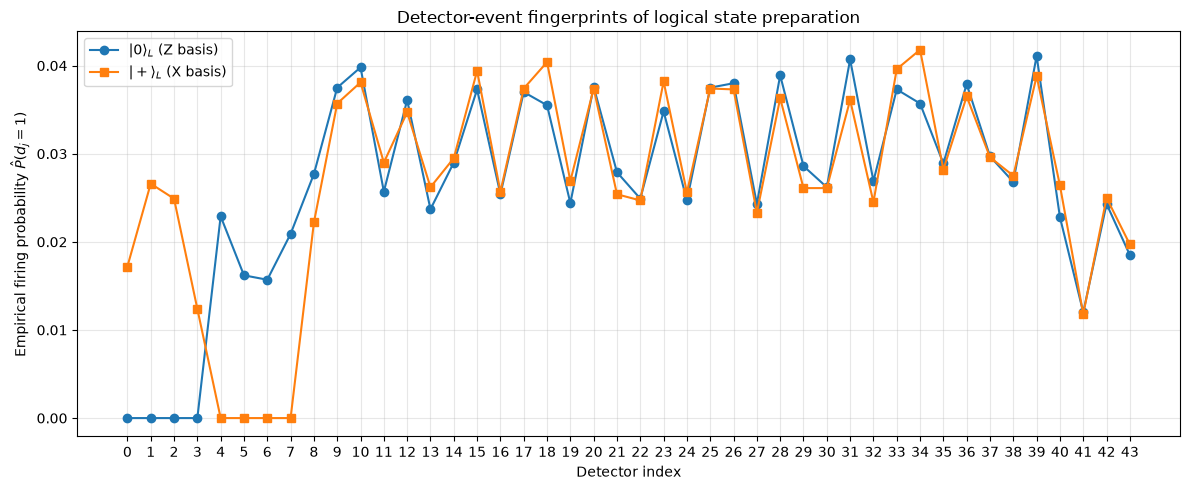

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Compare the empirical detector-event probabilities produced by
# the two logical memory preparations.
#
# Each point corresponds to one detector. The comparison is useful
# because a gate/state fingerprint is a property of the full
# detector distribution, not just its overall average.

detector_indices = np.arange(circuit_z.num_detectors)

plt.figure(figsize=(12, 5))

plt.plot(
    detector_indices,
    detector_rates_z,
    marker="o",
    label=r"$|0\rangle_L$ (Z basis)"
)

plt.plot(
    detector_indices,
    detector_rates_x,
    marker="s",
    label=r"$|+\rangle_L$ (X basis)"
)

plt.xlabel("Detector index")
plt.ylabel(r"Empirical firing probability $\hat{P}(d_j=1)$")
plt.title("Detector-event fingerprints of logical state preparation")

plt.xticks(detector_indices)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

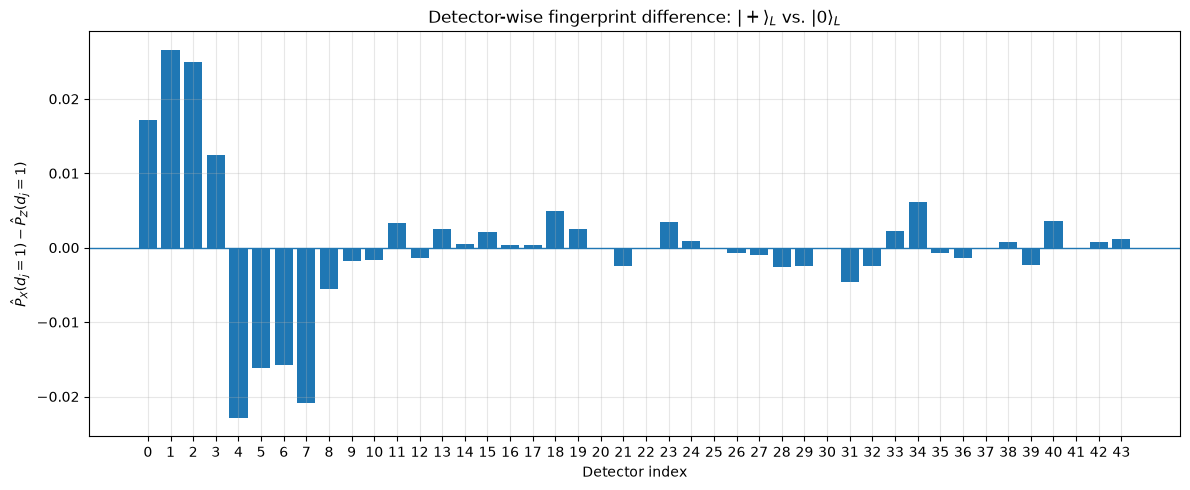

In [50]:
# Compute the detector-wise difference between the two
# logical state-preparation experiments.

fingerprint_difference = detector_rates_x - detector_rates_z

plt.figure(figsize=(12, 5))

plt.bar(
    detector_indices,
    fingerprint_difference
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Detector index")
plt.ylabel(r"$\hat{P}_X(d_j=1)-\hat{P}_Z(d_j=1)$")

plt.title(
    r"Detector-wise fingerprint difference: $|+\rangle_L$ vs. $|0\rangle_L$"
)

plt.xticks(detector_indices)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [54]:
# Retrieve the spacetime coordinates assigned to each detector.
# Stim stores these coordinates as a dictionary:
# detector index -> [x, y, t].

detector_coordinates = circuit_z.get_detector_coordinates()

print("Number of detector coordinates:", len(detector_coordinates))

for j in range(circuit_z.num_detectors):
    print(f"Detector {j:02d}: {detector_coordinates[j]}")

Number of detector coordinates: 44
Detector 00: [0.0, 2.0, 0.0]
Detector 01: [2.0, 4.0, 0.0]
Detector 02: [4.0, 2.0, 0.0]
Detector 03: [6.0, 4.0, 0.0]
Detector 04: [2.0, 2.0, 0.0]
Detector 05: [2.0, 6.0, 0.0]
Detector 06: [4.0, 0.0, 0.0]
Detector 07: [4.0, 4.0, 0.0]
Detector 08: [0.0, 2.0, 1.0]
Detector 09: [2.0, 4.0, 1.0]
Detector 10: [4.0, 2.0, 1.0]
Detector 11: [6.0, 4.0, 1.0]
Detector 12: [2.0, 2.0, 1.0]
Detector 13: [2.0, 6.0, 1.0]
Detector 14: [4.0, 0.0, 1.0]
Detector 15: [4.0, 4.0, 1.0]
Detector 16: [0.0, 2.0, 2.0]
Detector 17: [2.0, 4.0, 2.0]
Detector 18: [4.0, 2.0, 2.0]
Detector 19: [6.0, 4.0, 2.0]
Detector 20: [2.0, 2.0, 2.0]
Detector 21: [2.0, 6.0, 2.0]
Detector 22: [4.0, 0.0, 2.0]
Detector 23: [4.0, 4.0, 2.0]
Detector 24: [0.0, 2.0, 3.0]
Detector 25: [2.0, 4.0, 3.0]
Detector 26: [4.0, 2.0, 3.0]
Detector 27: [6.0, 4.0, 3.0]
Detector 28: [2.0, 2.0, 3.0]
Detector 29: [2.0, 6.0, 3.0]
Detector 30: [4.0, 0.0, 3.0]
Detector 31: [4.0, 4.0, 3.0]
Detector 32: [0.0, 2.0, 4.0]
Detector

In [57]:
# Group detectors by their time coordinate to reveal the
# temporal structure of the decoding window.

for j in range(circuit_z.num_detectors):
    x, y, t = detector_coordinates[j]
    print(f"Detector {j:02d}: x={x}, y={y}, t={t}")

Detector 00: x=0.0, y=2.0, t=0.0
Detector 01: x=2.0, y=4.0, t=0.0
Detector 02: x=4.0, y=2.0, t=0.0
Detector 03: x=6.0, y=4.0, t=0.0
Detector 04: x=2.0, y=2.0, t=0.0
Detector 05: x=2.0, y=6.0, t=0.0
Detector 06: x=4.0, y=0.0, t=0.0
Detector 07: x=4.0, y=4.0, t=0.0
Detector 08: x=0.0, y=2.0, t=1.0
Detector 09: x=2.0, y=4.0, t=1.0
Detector 10: x=4.0, y=2.0, t=1.0
Detector 11: x=6.0, y=4.0, t=1.0
Detector 12: x=2.0, y=2.0, t=1.0
Detector 13: x=2.0, y=6.0, t=1.0
Detector 14: x=4.0, y=0.0, t=1.0
Detector 15: x=4.0, y=4.0, t=1.0
Detector 16: x=0.0, y=2.0, t=2.0
Detector 17: x=2.0, y=4.0, t=2.0
Detector 18: x=4.0, y=2.0, t=2.0
Detector 19: x=6.0, y=4.0, t=2.0
Detector 20: x=2.0, y=2.0, t=2.0
Detector 21: x=2.0, y=6.0, t=2.0
Detector 22: x=4.0, y=0.0, t=2.0
Detector 23: x=4.0, y=4.0, t=2.0
Detector 24: x=0.0, y=2.0, t=3.0
Detector 25: x=2.0, y=4.0, t=3.0
Detector 26: x=4.0, y=2.0, t=3.0
Detector 27: x=6.0, y=4.0, t=3.0
Detector 28: x=2.0, y=2.0, t=3.0
Detector 29: x=2.0, y=6.0, t=3.0
Detector 3

In [55]:
# Quantify how different the detector-event distributions are
# between the two logical state-preparation experiments.

absolute_difference = np.abs(
    detector_rates_x - detector_rates_z
)

print("Mean absolute detector difference:",
      absolute_difference.mean())

print("Maximum absolute detector difference:",
      absolute_difference.max())

print(
    "Detector with maximum difference:",
    np.argmax(absolute_difference)
)

Mean absolute detector difference: 0.005095454545454545
Maximum absolute detector difference: 0.0266
Detector with maximum difference: 1


In [56]:
# Identify detectors with the largest observed differences.
# These are candidates for the most informative detector locations.

top_indices = np.argsort(absolute_difference)[::-1][:10]

for j in top_indices:
    print(
        f"Detector {j:02d}: "
        f"Z={detector_rates_z[j]:.5f}, "
        f"X={detector_rates_x[j]:.5f}, "
        f"|Δ|={absolute_difference[j]:.5f}"
    )

Detector 01: Z=0.00000, X=0.02660, |Δ|=0.02660
Detector 02: Z=0.00000, X=0.02490, |Δ|=0.02490
Detector 04: Z=0.02290, X=0.00000, |Δ|=0.02290
Detector 07: Z=0.02090, X=0.00000, |Δ|=0.02090
Detector 00: Z=0.00000, X=0.01720, |Δ|=0.01720
Detector 05: Z=0.01620, X=0.00000, |Δ|=0.01620
Detector 06: Z=0.01570, X=0.00000, |Δ|=0.01570
Detector 03: Z=0.00000, X=0.01240, |Δ|=0.01240
Detector 34: Z=0.03570, X=0.04180, |Δ|=0.00610
Detector 08: Z=0.02770, X=0.02220, |Δ|=0.00550


In [58]:
# Build a spacetime representation of the detector fingerprint.
# Each point shows where a detector is located in the surface-code
# patch and the magnitude/sign of the difference between the two
# logical state-preparation experiments.

coords = circuit_z.get_detector_coordinates()

x_coords = np.array([coords[j][0] for j in range(circuit_z.num_detectors)])
y_coords = np.array([coords[j][1] for j in range(circuit_z.num_detectors)])
t_coords = np.array([coords[j][2] for j in range(circuit_z.num_detectors)])

delta = detector_rates_x - detector_rates_z

print("Unique time coordinates:", np.unique(t_coords))

Unique time coordinates: [0.  1.  2.  3.  4.  4.5]


In [59]:
# Display the detector fingerprint separately for each
# syndrome-extraction time coordinate.

for t in np.unique(t_coords):
    mask = t_coords == t

    print(f"\nt = {t}")
    for j in np.where(mask)[0]:
        print(
            f"Detector {j:02d}: "
            f"(x={x_coords[j]:.1f}, y={y_coords[j]:.1f}), "
            f"Δ={delta[j]:+.5f}"
        )


t = 0.0
Detector 00: (x=0.0, y=2.0), Δ=+0.01720
Detector 01: (x=2.0, y=4.0), Δ=+0.02660
Detector 02: (x=4.0, y=2.0), Δ=+0.02490
Detector 03: (x=6.0, y=4.0), Δ=+0.01240
Detector 04: (x=2.0, y=2.0), Δ=-0.02290
Detector 05: (x=2.0, y=6.0), Δ=-0.01620
Detector 06: (x=4.0, y=0.0), Δ=-0.01570
Detector 07: (x=4.0, y=4.0), Δ=-0.02090

t = 1.0
Detector 08: (x=0.0, y=2.0), Δ=-0.00550
Detector 09: (x=2.0, y=4.0), Δ=-0.00180
Detector 10: (x=4.0, y=2.0), Δ=-0.00170
Detector 11: (x=6.0, y=4.0), Δ=+0.00330
Detector 12: (x=2.0, y=2.0), Δ=-0.00140
Detector 13: (x=2.0, y=6.0), Δ=+0.00250
Detector 14: (x=4.0, y=0.0), Δ=+0.00050
Detector 15: (x=4.0, y=4.0), Δ=+0.00210

t = 2.0
Detector 16: (x=0.0, y=2.0), Δ=+0.00030
Detector 17: (x=2.0, y=4.0), Δ=+0.00040
Detector 18: (x=4.0, y=2.0), Δ=+0.00490
Detector 19: (x=6.0, y=4.0), Δ=+0.00250
Detector 20: (x=2.0, y=2.0), Δ=-0.00020
Detector 21: (x=2.0, y=6.0), Δ=-0.00250
Detector 22: (x=4.0, y=0.0), Δ=-0.00020
Detector 23: (x=4.0, y=4.0), Δ=+0.00340

t = 3.0
Dete

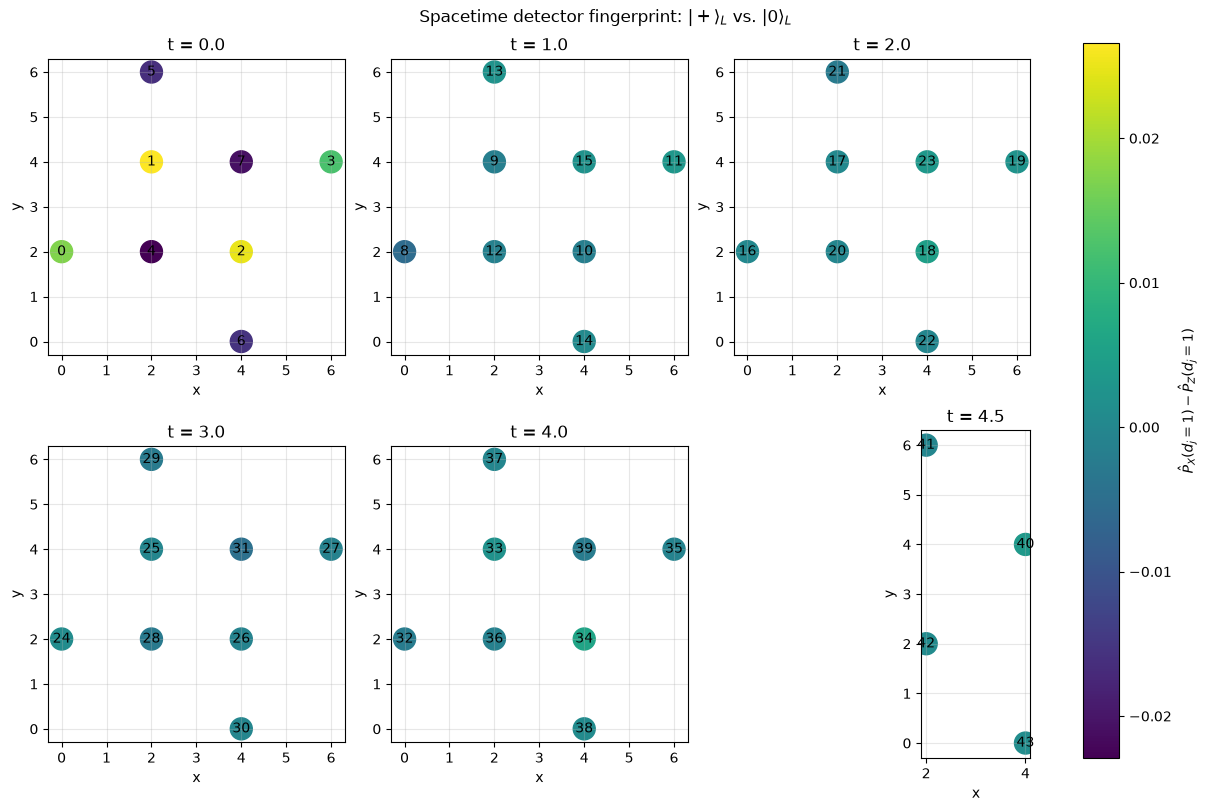

In [63]:
# Visualize the detector fingerprint across space and time.
# All time slices use the same color scale so that detector differences
# can be compared directly across the entire decoding window.

unique_times = np.unique(t_coords)

# Use one common scale for all detector differences.
vmin = delta.min()
vmax = delta.max()

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    constrained_layout=True
)

axes = axes.flatten()

for ax, t in zip(axes, unique_times):
    mask = t_coords == t

    scatter = ax.scatter(
        x_coords[mask],
        y_coords[mask],
        c=delta[mask],
        vmin=vmin,
        vmax=vmax,
        s=250
    )

    # Label each detector with its index.
    for j in np.where(mask)[0]:
        ax.text(
            x_coords[j],
            y_coords[j],
            str(j),
            ha="center",
            va="center"
        )

    ax.set_title(f"t = {t}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

# Use one shared colorbar with the same scale for all panels.
fig.colorbar(
    scatter,
    ax=axes.tolist(),
    label=r"$\hat{P}_X(d_j=1)-\hat{P}_Z(d_j=1)$"
)

fig.suptitle(
    r"Spacetime detector fingerprint: $|+\rangle_L$ vs. $|0\rangle_L$"
)

plt.show()

In [65]:
# Inspect the qubit roles in the rotated surface-code layout.
# The layout distinguishes data qubits from ancilla qubits used
# for stabilizer measurements.

print("Data qubits:")
print(layout.data_qubits)

print("\nAncilla qubits:")
print(layout.anc_qubits)

print("\nAll qubit indices:")
print(layout.qubit_inds)

Data qubits:
('D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9')

Ancilla qubits:
('X1', 'X2', 'X3', 'X4', 'Z1', 'Z2', 'Z3', 'Z4')

All qubit indices:
{'D1': 0, 'D2': 1, 'D3': 2, 'D4': 3, 'D5': 4, 'D6': 5, 'D7': 6, 'D8': 7, 'D9': 8, 'X1': 9, 'X2': 10, 'X3': 11, 'X4': 12, 'Z1': 13, 'Z2': 14, 'Z3': 15, 'Z4': 16}


In [66]:
# Inspect the available layout metadata related to ancilla qubits
# and stabilizer measurements.

print([
    name
    for name in dir(layout)
    if "stab" in name.lower()
    or "anc" in name.lower()
    or "param" in name.lower()
])

['anc_coords', 'anc_qubits', 'distance', 'distance_x', 'distance_z', 'logical_param', 'num_anc_qubits', 'param', 'set_logical_param', 'set_param']


In [67]:
# Inspect the ancilla coordinates and verify the spatial locations
# associated with the X-type and Z-type stabilizer measurements.

print("X-type ancilla qubits:")
for q in layout.anc_qubits:
    if q.startswith("X"):
        print(q, "->", layout.anc_coords[q])

print("\nZ-type ancilla qubits:")
for q in layout.anc_qubits:
    if q.startswith("Z"):
        print(q, "->", layout.anc_coords[q])

X-type ancilla qubits:
X1 -> (0, 2)
X2 -> (2, 4)
X3 -> (4, 2)
X4 -> (6, 4)

Z-type ancilla qubits:
Z1 -> (2, 2)
Z2 -> (2, 6)
Z3 -> (4, 0)
Z4 -> (4, 4)


In [68]:
# Compare the detector-event rates of the two stabilizer families
# at the beginning of the decoding window.

initial_detectors = np.arange(8)

x_family_detectors = initial_detectors[:4]
z_family_detectors = initial_detectors[4:8]

print("Initial X-family detectors:", x_family_detectors)
print("Initial Z-family detectors:", z_family_detectors)

print("\n|0>_L preparation:")
print(
    "X-family mean:",
    detector_rates_z[x_family_detectors].mean()
)
print(
    "Z-family mean:",
    detector_rates_z[z_family_detectors].mean()
)

print("\n|+>_L preparation:")
print(
    "X-family mean:",
    detector_rates_x[x_family_detectors].mean()
)
print(
    "Z-family mean:",
    detector_rates_x[z_family_detectors].mean()
)

Initial X-family detectors: [0 1 2 3]
Initial Z-family detectors: [4 5 6 7]

|0>_L preparation:
X-family mean: 0.0
Z-family mean: 0.018924999999999997

|+>_L preparation:
X-family mean: 0.020274999999999998
Z-family mean: 0.0
